# Create table and txs

In [2]:
import os
import subprocess
import glob

# ------------------------------------------------------------------------------
# Configuration: Paths to the Python scripts (relative to the notebook)
# ------------------------------------------------------------------------------
gen_tables_path = os.path.join("gen_py", "gen_tables.py")           # Path to gen_tables.py
gen_inc_update_path = os.path.join("gen_py", "gen_inc_update.py")     # Path to gen_inc_update.py

# CSV folder is assumed to be at ../csv relative to the scripts
csv_dir = os.path.join(os.path.dirname(os.path.abspath(gen_tables_path)), "..", "csv")

# ------------------------------------------------------------------------------
# 1) Delete existing CSV files in CSV folder
# ------------------------------------------------------------------------------
print(f"Deleting existing CSV files in: {csv_dir}")
if os.path.exists(csv_dir):
    for f in glob.glob(os.path.join(csv_dir, "*.csv")):
        os.remove(f)
    print("Old CSV files deleted.\n")
else:
    print("CSV folder does not exist. It will be created by the scripts.\n")

# ------------------------------------------------------------------------------
# 2) Run gen_tables.py to generate tables
# ------------------------------------------------------------------------------
cmd_tables = [
    "python3", gen_tables_path,   # Run gen_tables.py using python3
    "-T", "2",                    # Number of tables to generate (table_0.csv, table_1.csv)
    "-r", "10000",                # Number of rows per table (applies to all tables)
    "-jks", "100",                # Join key pool size
    "-jk", "100",                 # Join key size
    "-pk", "100",                 # Primary key size
    "-minv", "984",               # Minimum value length
    "-maxv", "984"                # Maximum value length
]

print("Running gen_tables.py with command:")
print(" ".join(cmd_tables), "\n")
result_tables = subprocess.run(cmd_tables, capture_output=True, text=True)
print("gen_tables.py STDOUT:")
print(result_tables.stdout)
print("gen_tables.py STDERR:")
print(result_tables.stderr)

# ------------------------------------------------------------------------------
# 3) Run gen_inc_update.py to generate incremental update logs and join logs
# ------------------------------------------------------------------------------
# Here we pass:
# - Base table file name for table_0 ("table_0.csv")
# - Number of transactions per coverage file (-ntx)
# - Minimum, maximum, and step coverage fractions (as configurable parameters)
# - Operation ratios (we assume only updates, so update_ratio=1, others=0)
# - Join TX configuration (-tjt)
# - And the new ts-values list for join logs (--ts-values)
cmd_inc_update = [
    "python3", gen_inc_update_path,
    "-t0", "table_0.csv",         # Base table_0 CSV filename
    "-ntx", "10",                  # Number of transactions for each coverage log
    "-mintx", "0.1",              # Minimum coverage fraction (e.g., 0.1 for 10%)
    "-maxtx", "1.0",              # Maximum coverage fraction (e.g., 1.0 for 100%)
    "-steptx", "0.1",             # Step size (e.g., 0.1 => 10% increments)
    "-ir", "0",                   # Insert ratio (0 if only updates)
    "-gr", "0",                   # Get ratio
    "-ur", "1",                   # Update ratio
    "-dr", "0",                   # Delete ratio
    "-tjt", "1",                 # Number of transactions for each discovered join table
    "--ts-values", "1", "100"  # TS values list for join logs
]

print("\nRunning gen_inc_update.py with command:")
print(" ".join(cmd_inc_update), "\n")
result_inc_update = subprocess.run(cmd_inc_update, capture_output=True, text=True)
print("gen_inc_update.py STDOUT:")
print(result_inc_update.stdout)
print("gen_inc_update.py STDERR:")
print(result_inc_update.stderr)


Deleting existing CSV files in: /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv
Old CSV files deleted.

Running gen_tables.py with command:
python3 gen_py/gen_tables.py -T 2 -r 10000 -jks 100 -jk 100 -pk 100 -minv 984 -maxv 984 

gen_tables.py STDOUT:
Generating a join key pool of size 100 (each key length = 100) ...
  -> /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/key_pool.csv (contains 100 keys).
Generating /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/table_0.csv with 10000 rows...
  -> /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/table_0.csv generated.
Generating /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/benches/hash_join/join_simulation/gen_py/../csv/table_1.csv with 10000 rows...
  -> /Users/jun/Desktop/dev/mbp16/crustydb/riki/FosterBtree/ben

# Run join_simulation.rs

Discovered coverage logs:
  coverage label='u0.1' => file=txs_u0.1_t0.csv
  coverage label='u0.2' => file=txs_u0.2_t0.csv
  coverage label='u0.3' => file=txs_u0.3_t0.csv
  coverage label='u0.4' => file=txs_u0.4_t0.csv
  coverage label='u0.5' => file=txs_u0.5_t0.csv
  coverage label='u0.6' => file=txs_u0.6_t0.csv
  coverage label='u0.7' => file=txs_u0.7_t0.csv
  coverage label='u0.8' => file=txs_u0.8_t0.csv
  coverage label='u0.9' => file=txs_u0.9_t0.csv
  coverage label='u1.0' => file=txs_u1.0_t0.csv

=== Coverage label='u0.1', file=txs_u0.1_t0.csv, hash_type=open_address ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== Coverage label='u0.1', file=txs_u0.1_t0.csv, hash_type=chain ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== Coverage label='u0.1', file=txs_u0.1_t0.csv, hash_type=heap ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== Coverage label='u0.1', file=txs_u0.1_t0.csv, hash_type=rust ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== 

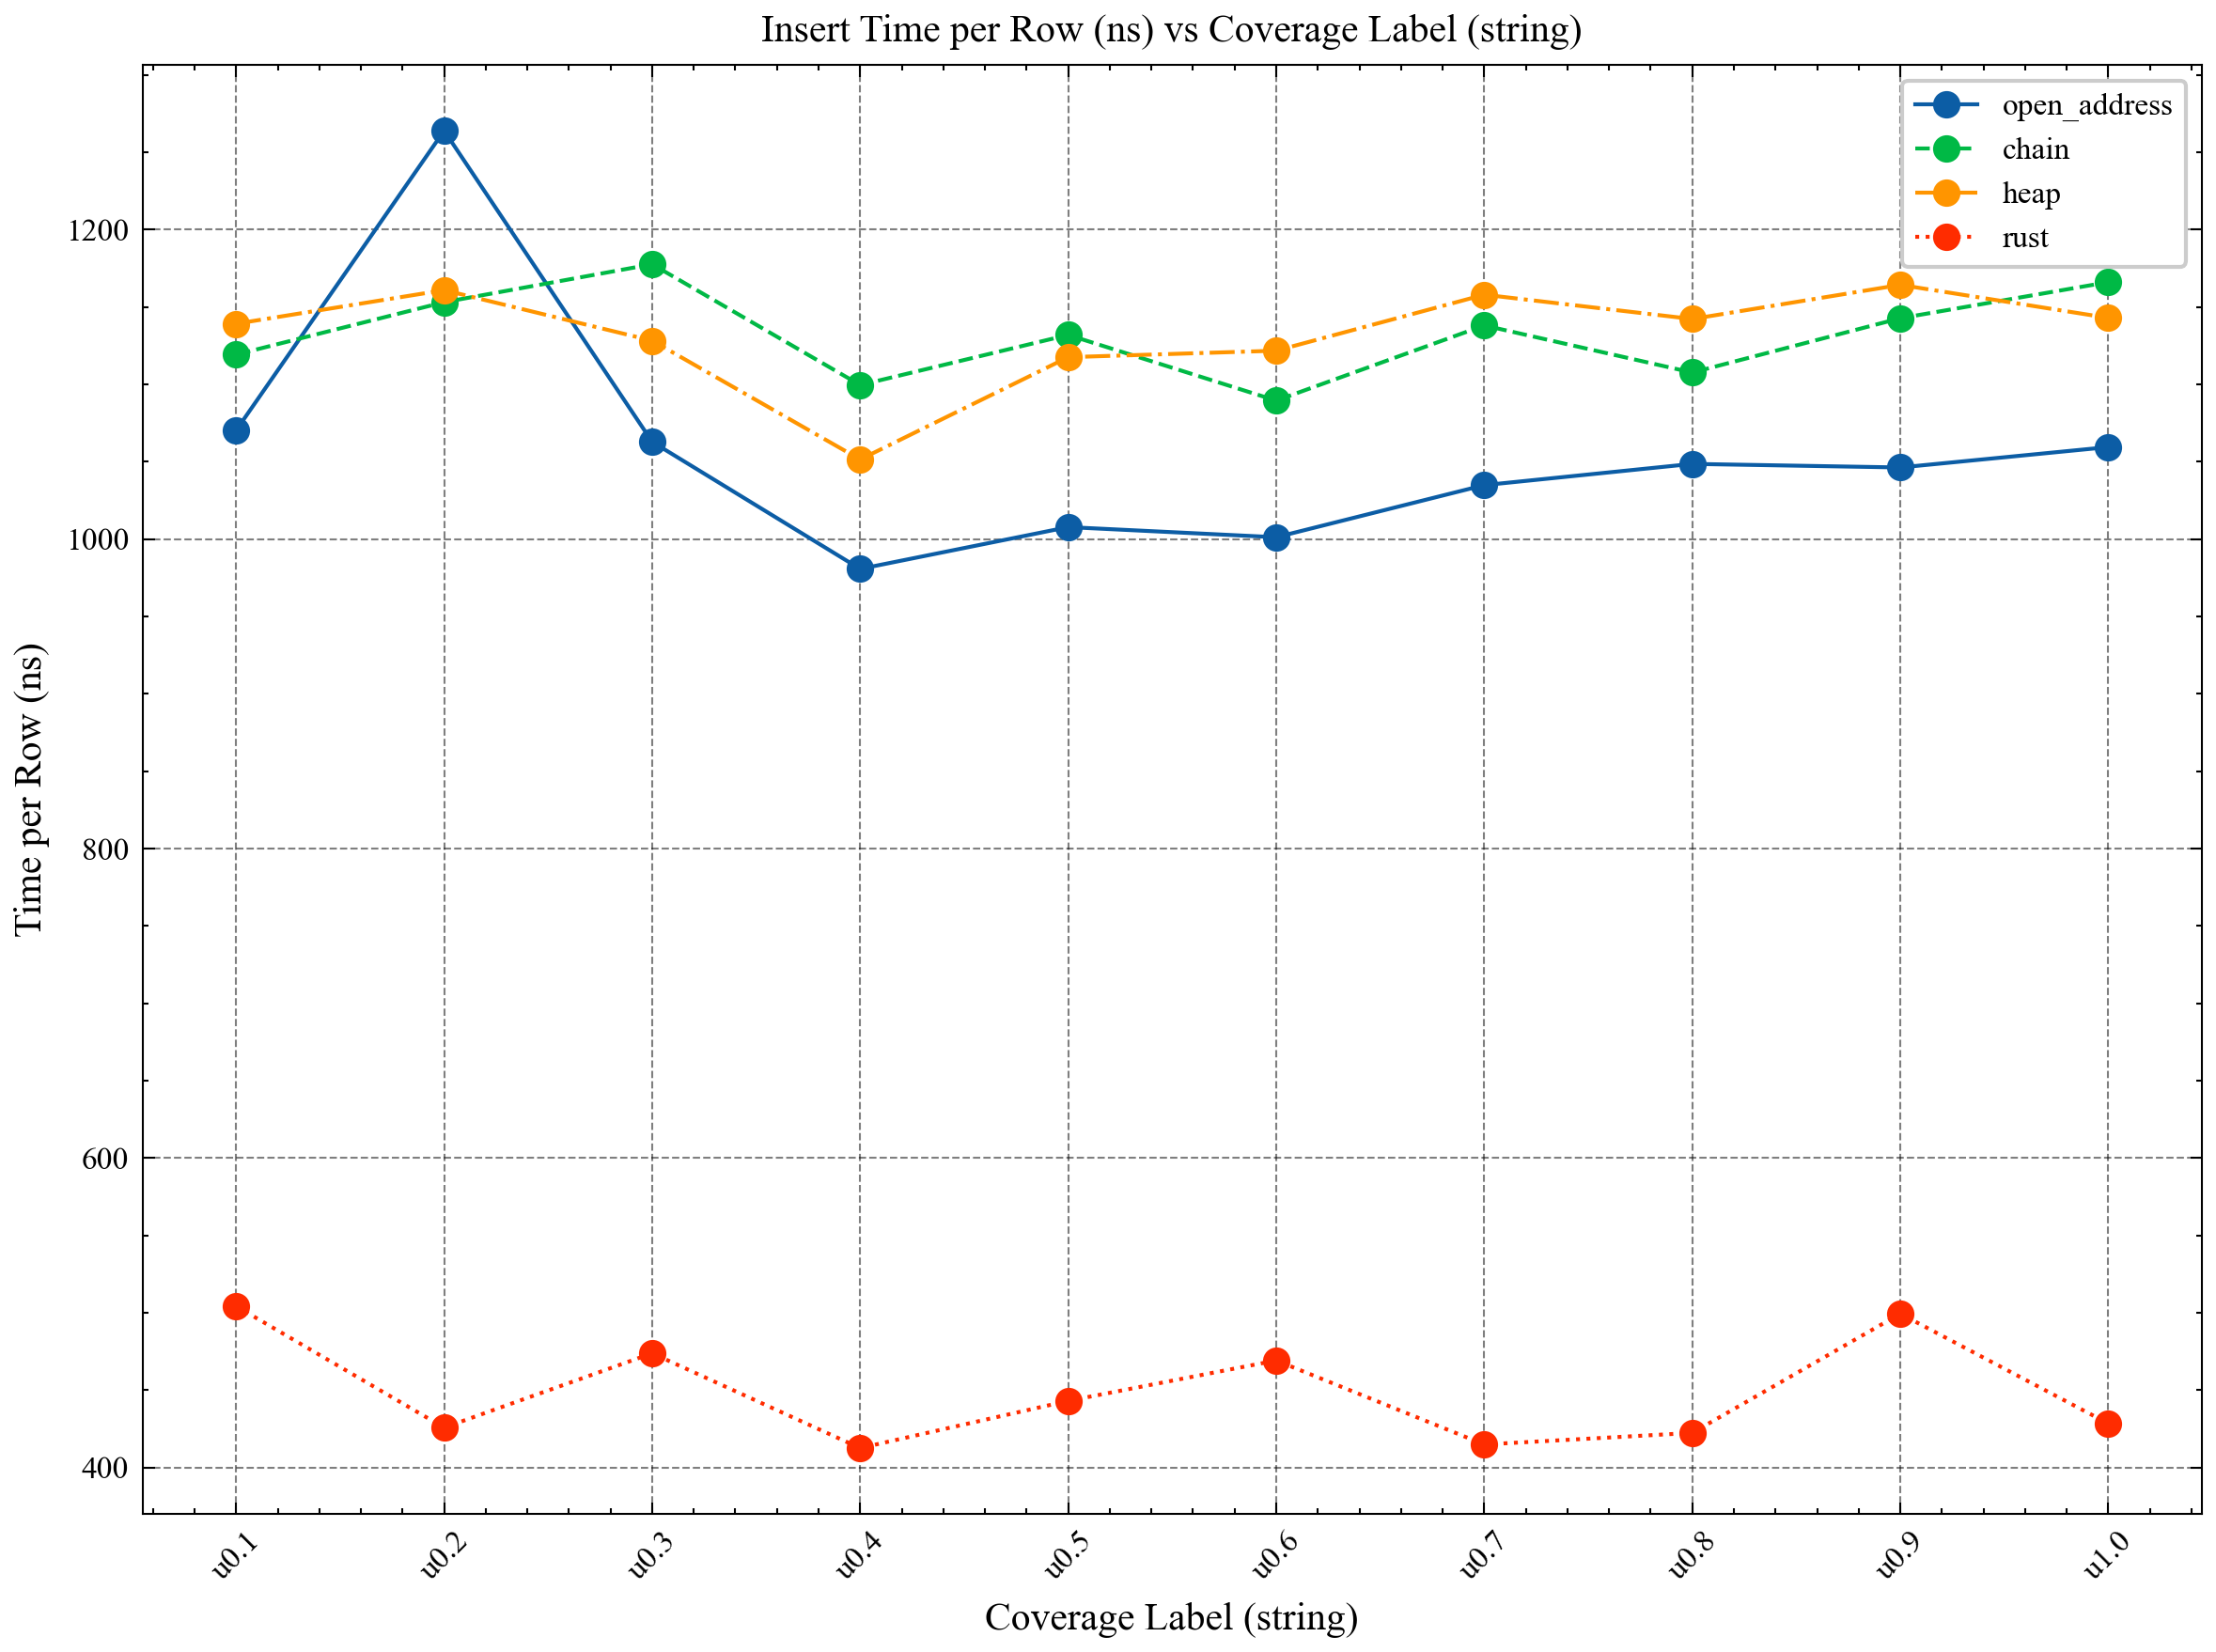

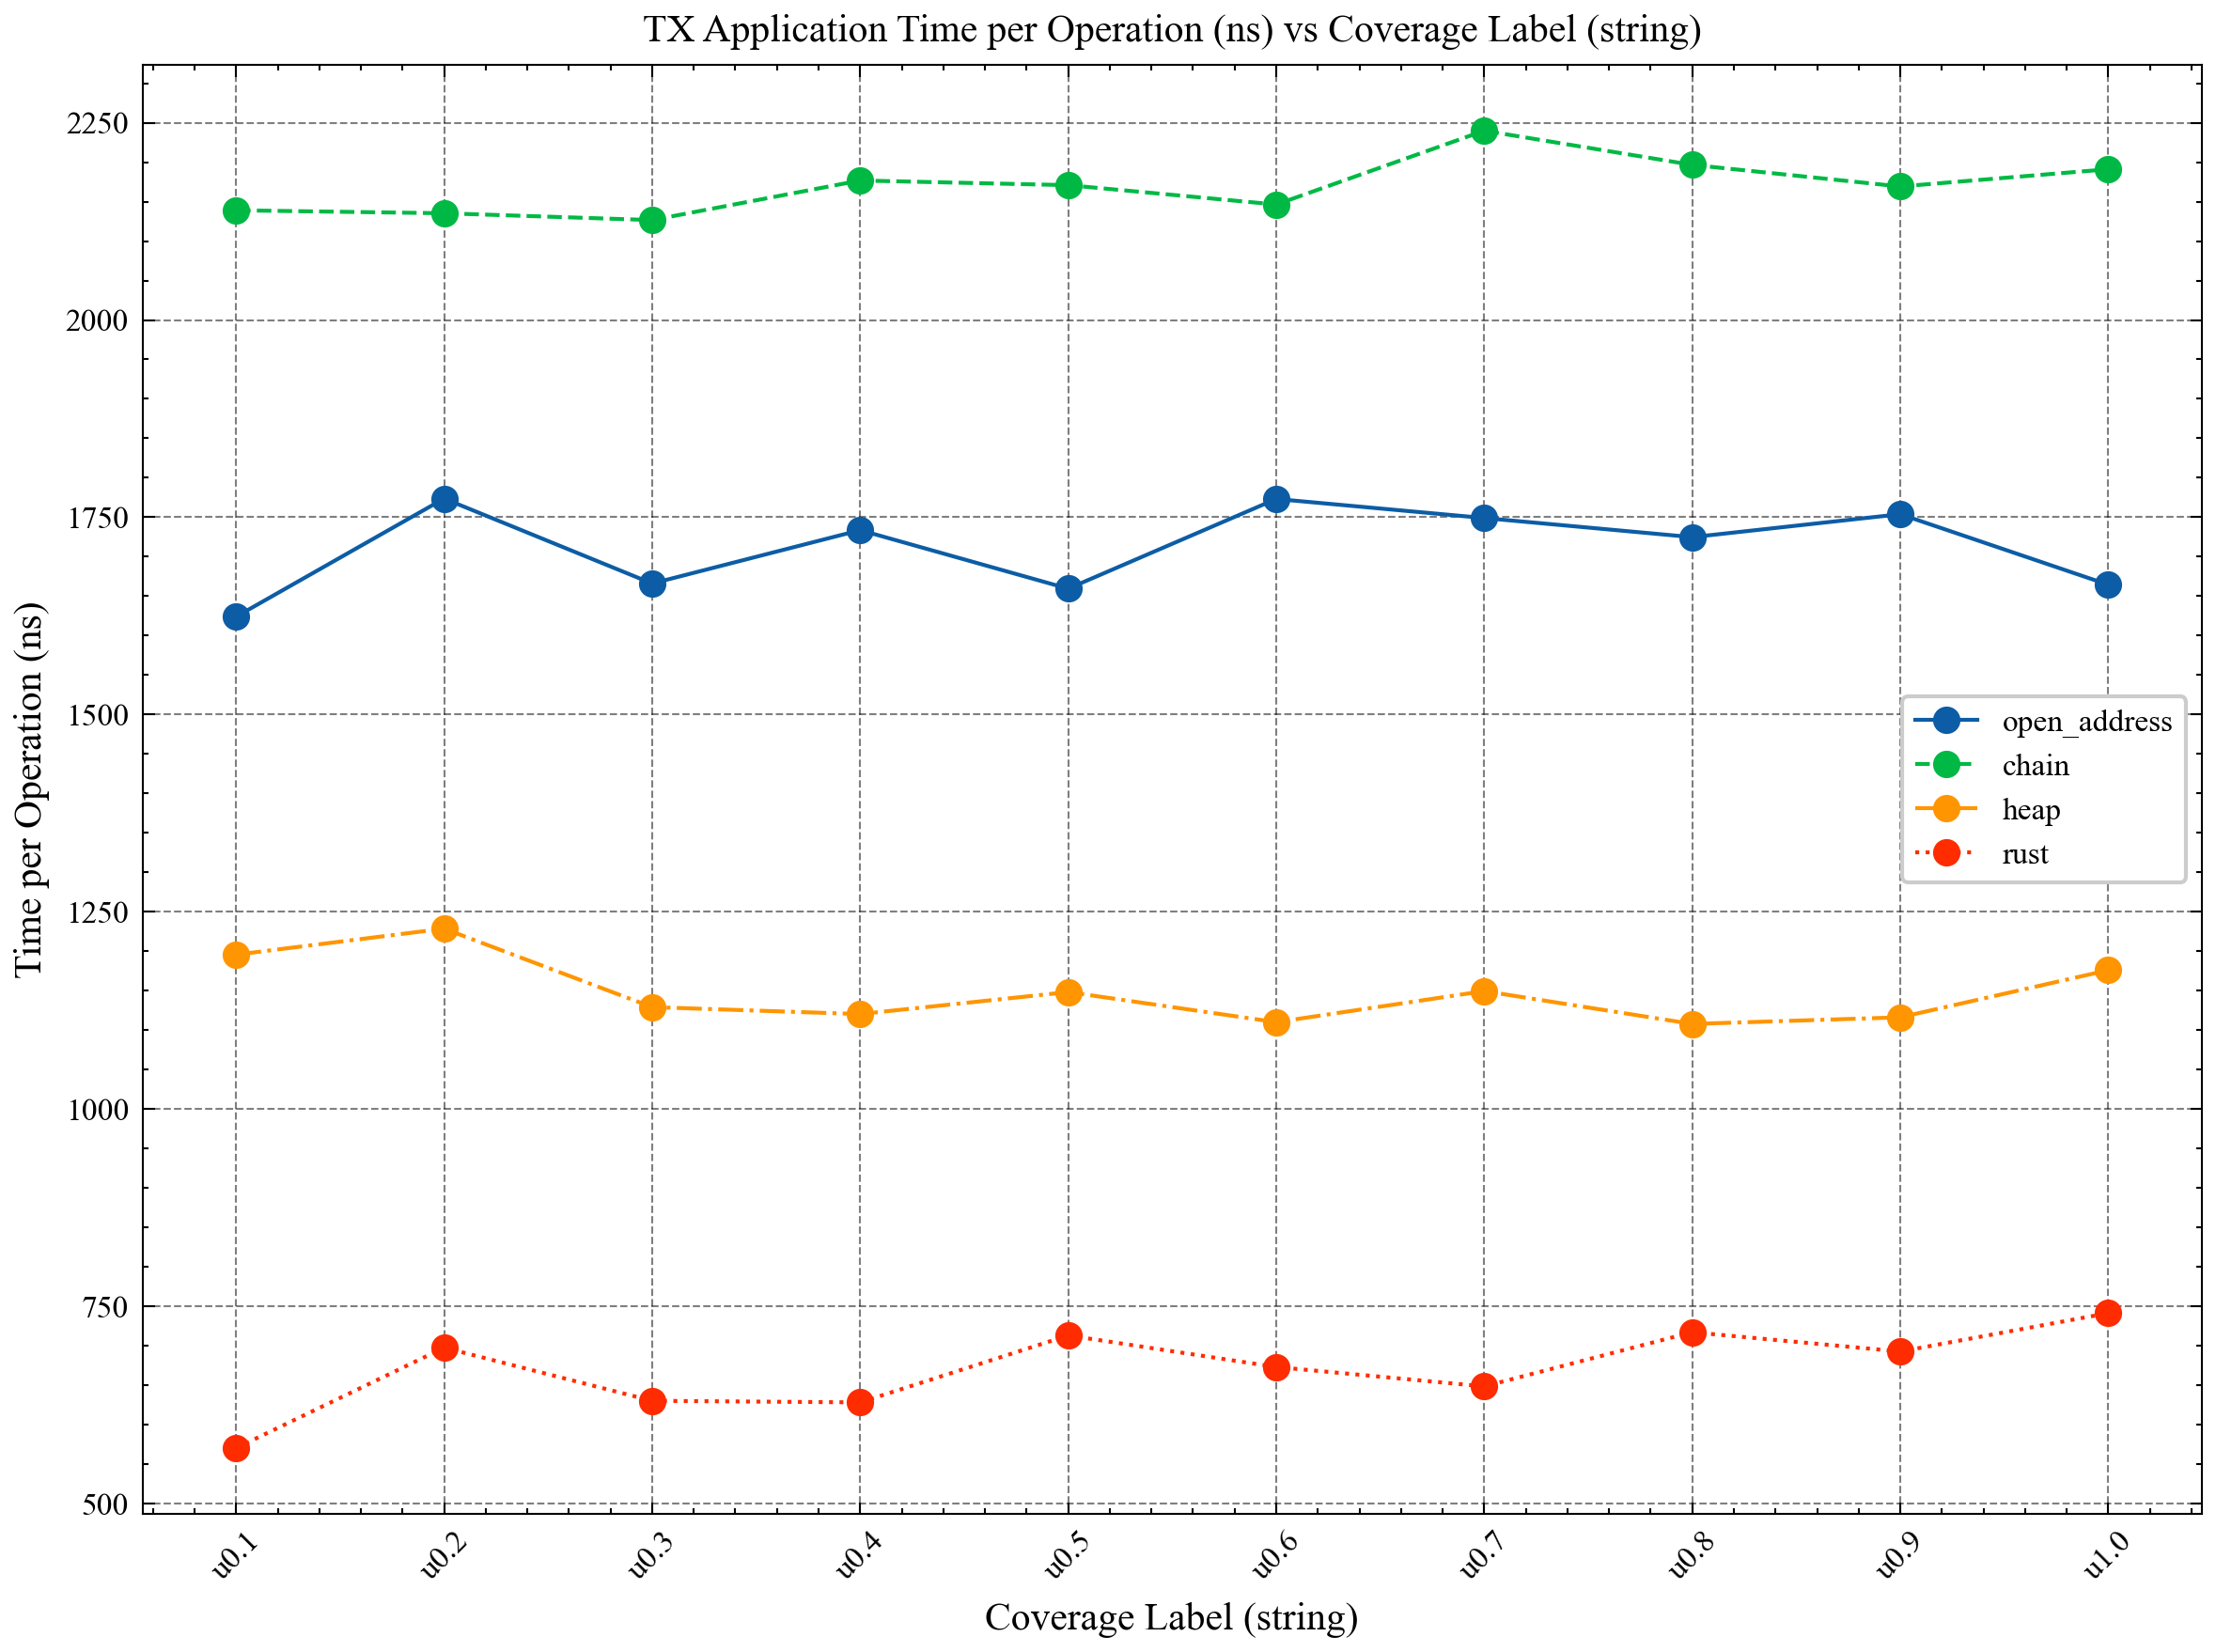

In [26]:
import subprocess
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# --------------------------------------------------------------------------
# 1) Discover coverage logs named like "txs_{SOMETHING}_t0.csv"
# --------------------------------------------------------------------------
csv_dir = os.path.abspath(os.path.join("csv"))
if not os.path.exists(csv_dir):
    print("Error: CSV folder not found at", csv_dir)
    raise SystemExit(1)

all_files = os.listdir(csv_dir)
coverage_logs = sorted(
    f for f in all_files
    if f.startswith("txs_") and f.endswith("_t0.csv")
)
if not coverage_logs:
    print("No coverage logs found matching txs_*_t0.csv")
    raise SystemExit(0)

# Let's keep coverage_labels in the same order we discovered them
coverage_labels = [f[4:-7] for f in coverage_logs]
# e.g. if f="txs_u0.1_t0.csv", then f[4:-7] => "u0.1"

print("Discovered coverage logs:")
for lbl, f in zip(coverage_labels, coverage_logs):
    print(f"  coverage label='{lbl}' => file={f}")

# --------------------------------------------------------------------------
# 2) Define your hash table types and run parameters
# --------------------------------------------------------------------------
hash_types = ["open_address", "chain", "heap", "rust"]
num_iterations = 3  # times to run each coverage & type
# The path to your compiled Rust binary
binary_path = os.path.abspath(os.path.join("..", "..", "..", "target", "release", "join_simulation"))
if not os.path.exists(binary_path):
    print("Error: binary not found at", binary_path)
    raise SystemExit(1)

# Patterns to parse Insert/Applied from your Rust code output
insert_pattern = re.compile(r"Inserted\s+(\d+)\s+rows\s+from\s+\"[^\"]+\"\s+in\s+(\d+)\s+ns")
applied_pattern = re.compile(r"Applied\s+(\d+)\s+operations\s+from\s+\"([^\"]+)\"\s+in\s+(\d+)\s+ns")

results = []

# --------------------------------------------------------------------------
# 3) For each coverage label & file, run 4 hash table types
# --------------------------------------------------------------------------
for lbl, ops_file in zip(coverage_labels, coverage_logs):
    ops_path = os.path.join(csv_dir, ops_file)
    
    for ht in hash_types:
        insert_times, insert_counts = [], []
        applied_times, applied_counts = [], []
        
        print(f"\n=== Coverage label='{lbl}', file={ops_file}, hash_type={ht} ===")
        for iteration in range(num_iterations):
            print(f"   iteration {iteration+1}/{num_iterations}")
            cmd = [
                binary_path,
                "--csv-dir", csv_dir,      # recognized by your Rust code
                "--table0", "table_0.csv", # recognized by your Rust code
                "--txs0", ops_file,        # recognized by your Rust code
                "-t", ht                   # recognized by your Rust code
            ]
            proc = subprocess.run(cmd, capture_output=True, text=True)
            if proc.returncode != 0:
                print(f"[ERROR] coverage={lbl}, type={ht}, iteration={iteration+1}")
                print(proc.stderr)
                continue
            
            stdout = proc.stdout
            
            # Parse Insert line => "Inserted <N> rows ... in <ns> ns"
            m_insert = insert_pattern.search(stdout)
            if m_insert:
                row_count = int(m_insert.group(1))
                time_ns = int(m_insert.group(2))
                insert_times.append(time_ns)
                insert_counts.append(row_count)
            
            # Parse the relevant 'Applied' line referencing our ops file
            matches = applied_pattern.findall(stdout)
            relevant_time_ns = None
            relevant_op_count = None
            for (ops_count_str, fname_str, time_ns_str) in matches:
                if fname_str == ops_file:
                    relevant_time_ns = int(time_ns_str)
                    relevant_op_count = int(ops_count_str)
                    break
            if relevant_time_ns:
                applied_times.append(relevant_time_ns)
                applied_counts.append(relevant_op_count)
        
        # Calculate average time per row or op
        if insert_times and insert_counts:
            avg_insert_time = sum(insert_times)/len(insert_times)
            avg_insert_count = sum(insert_counts)/len(insert_counts)
            insert_time_per_row = avg_insert_time / avg_insert_count
        else:
            insert_time_per_row = math.nan
        
        if applied_times and applied_counts:
            avg_applied_time = sum(applied_times)/len(applied_times)
            avg_applied_count = sum(applied_counts)/len(applied_counts)
            applied_time_per_op = avg_applied_time / avg_applied_count
        else:
            applied_time_per_op = math.nan
        
        results.append({
            "coverage_str": lbl,  # store the string coverage label
            "hash_type": ht,
            "insert_time_per_row_ns": insert_time_per_row,
            "applied_time_per_op_ns": applied_time_per_op
        })

# --------------------------------------------------------------------------
# 4) Build DataFrame, do a line plot with coverage_str as categorical x
# --------------------------------------------------------------------------
df = pd.DataFrame(results)
if df.empty:
    print("No valid results.")
else:
    print("\n=== Summary DataFrame ===")
    print(df)

    # We want coverage_labels in the same order we discovered them
    # Let's create a mapping coverage_label -> integer x position
    coverage_index = {lbl: i for i, lbl in enumerate(coverage_labels)}

    # Sort the coverage in that custom order
    # We'll store an integer x-position for each row
    df["x_pos"] = df["coverage_str"].map(coverage_index)

    # We'll do 2 line plots (insert_time_per_row, applied_time_per_op)
    # Each hash_type gets a line
    # We'll label the x-axis with the coverage_str
    x_ticks = np.arange(len(coverage_labels))  # 0..N-1
    x_labels = coverage_labels                # the strings

    # 1) Insert time per row
    plt.figure(figsize=(8,6))
    for ht in hash_types:
        sub = df[df["hash_type"] == ht].copy()
        # sort by x_pos to ensure the line is drawn in the correct order
        sub.sort_values("x_pos", inplace=True)
        plt.plot(sub["x_pos"], sub["insert_time_per_row_ns"], marker="o", label=ht)
    plt.title("Insert Time per Row (ns) vs Coverage Label (string)")
    plt.xlabel("Coverage Label (string)")
    plt.ylabel("Time per Row (ns)")
    plt.xticks(x_ticks, x_labels, rotation=45)  # rotate if needed
    plt.legend()
    plt.tight_layout()
    plt.show()

    # 2) Applied time per op
    plt.figure(figsize=(8,6))
    for ht in hash_types:
        sub = df[df["hash_type"] == ht].copy()
        sub.sort_values("x_pos", inplace=True)
        plt.plot(sub["x_pos"], sub["applied_time_per_op_ns"], marker="o", label=ht)
    plt.title("TX Application Time per Operation (ns) vs Coverage Label (string)")
    plt.xlabel("Coverage Label (string)")
    plt.ylabel("Time per Operation (ns)")
    plt.xticks(x_ticks, x_labels, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

=== Building Rust binary (join_simulation) in release mode ===
Cargo build completed successfully.

Discovered coverage logs:
  coverage label='u0.1' => file=txs_u0.1_t0.csv
  coverage label='u0.2' => file=txs_u0.2_t0.csv
  coverage label='u0.3' => file=txs_u0.3_t0.csv
  coverage label='u0.4' => file=txs_u0.4_t0.csv
  coverage label='u0.5' => file=txs_u0.5_t0.csv
  coverage label='u0.6' => file=txs_u0.6_t0.csv
  coverage label='u0.7' => file=txs_u0.7_t0.csv
  coverage label='u0.8' => file=txs_u0.8_t0.csv
  coverage label='u0.9' => file=txs_u0.9_t0.csv
  coverage label='u1.0' => file=txs_u1.0_t0.csv

=== coverage='u0.1', file=txs_u0.1_t0.csv, hash_type=open_address ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== coverage='u0.1', file=txs_u0.1_t0.csv, hash_type=chain ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== coverage='u0.1', file=txs_u0.1_t0.csv, hash_type=heap ===
   iteration 1/3
   iteration 2/3
   iteration 3/3

=== coverage='u0.1', file=txs_u0.1_t0.csv,

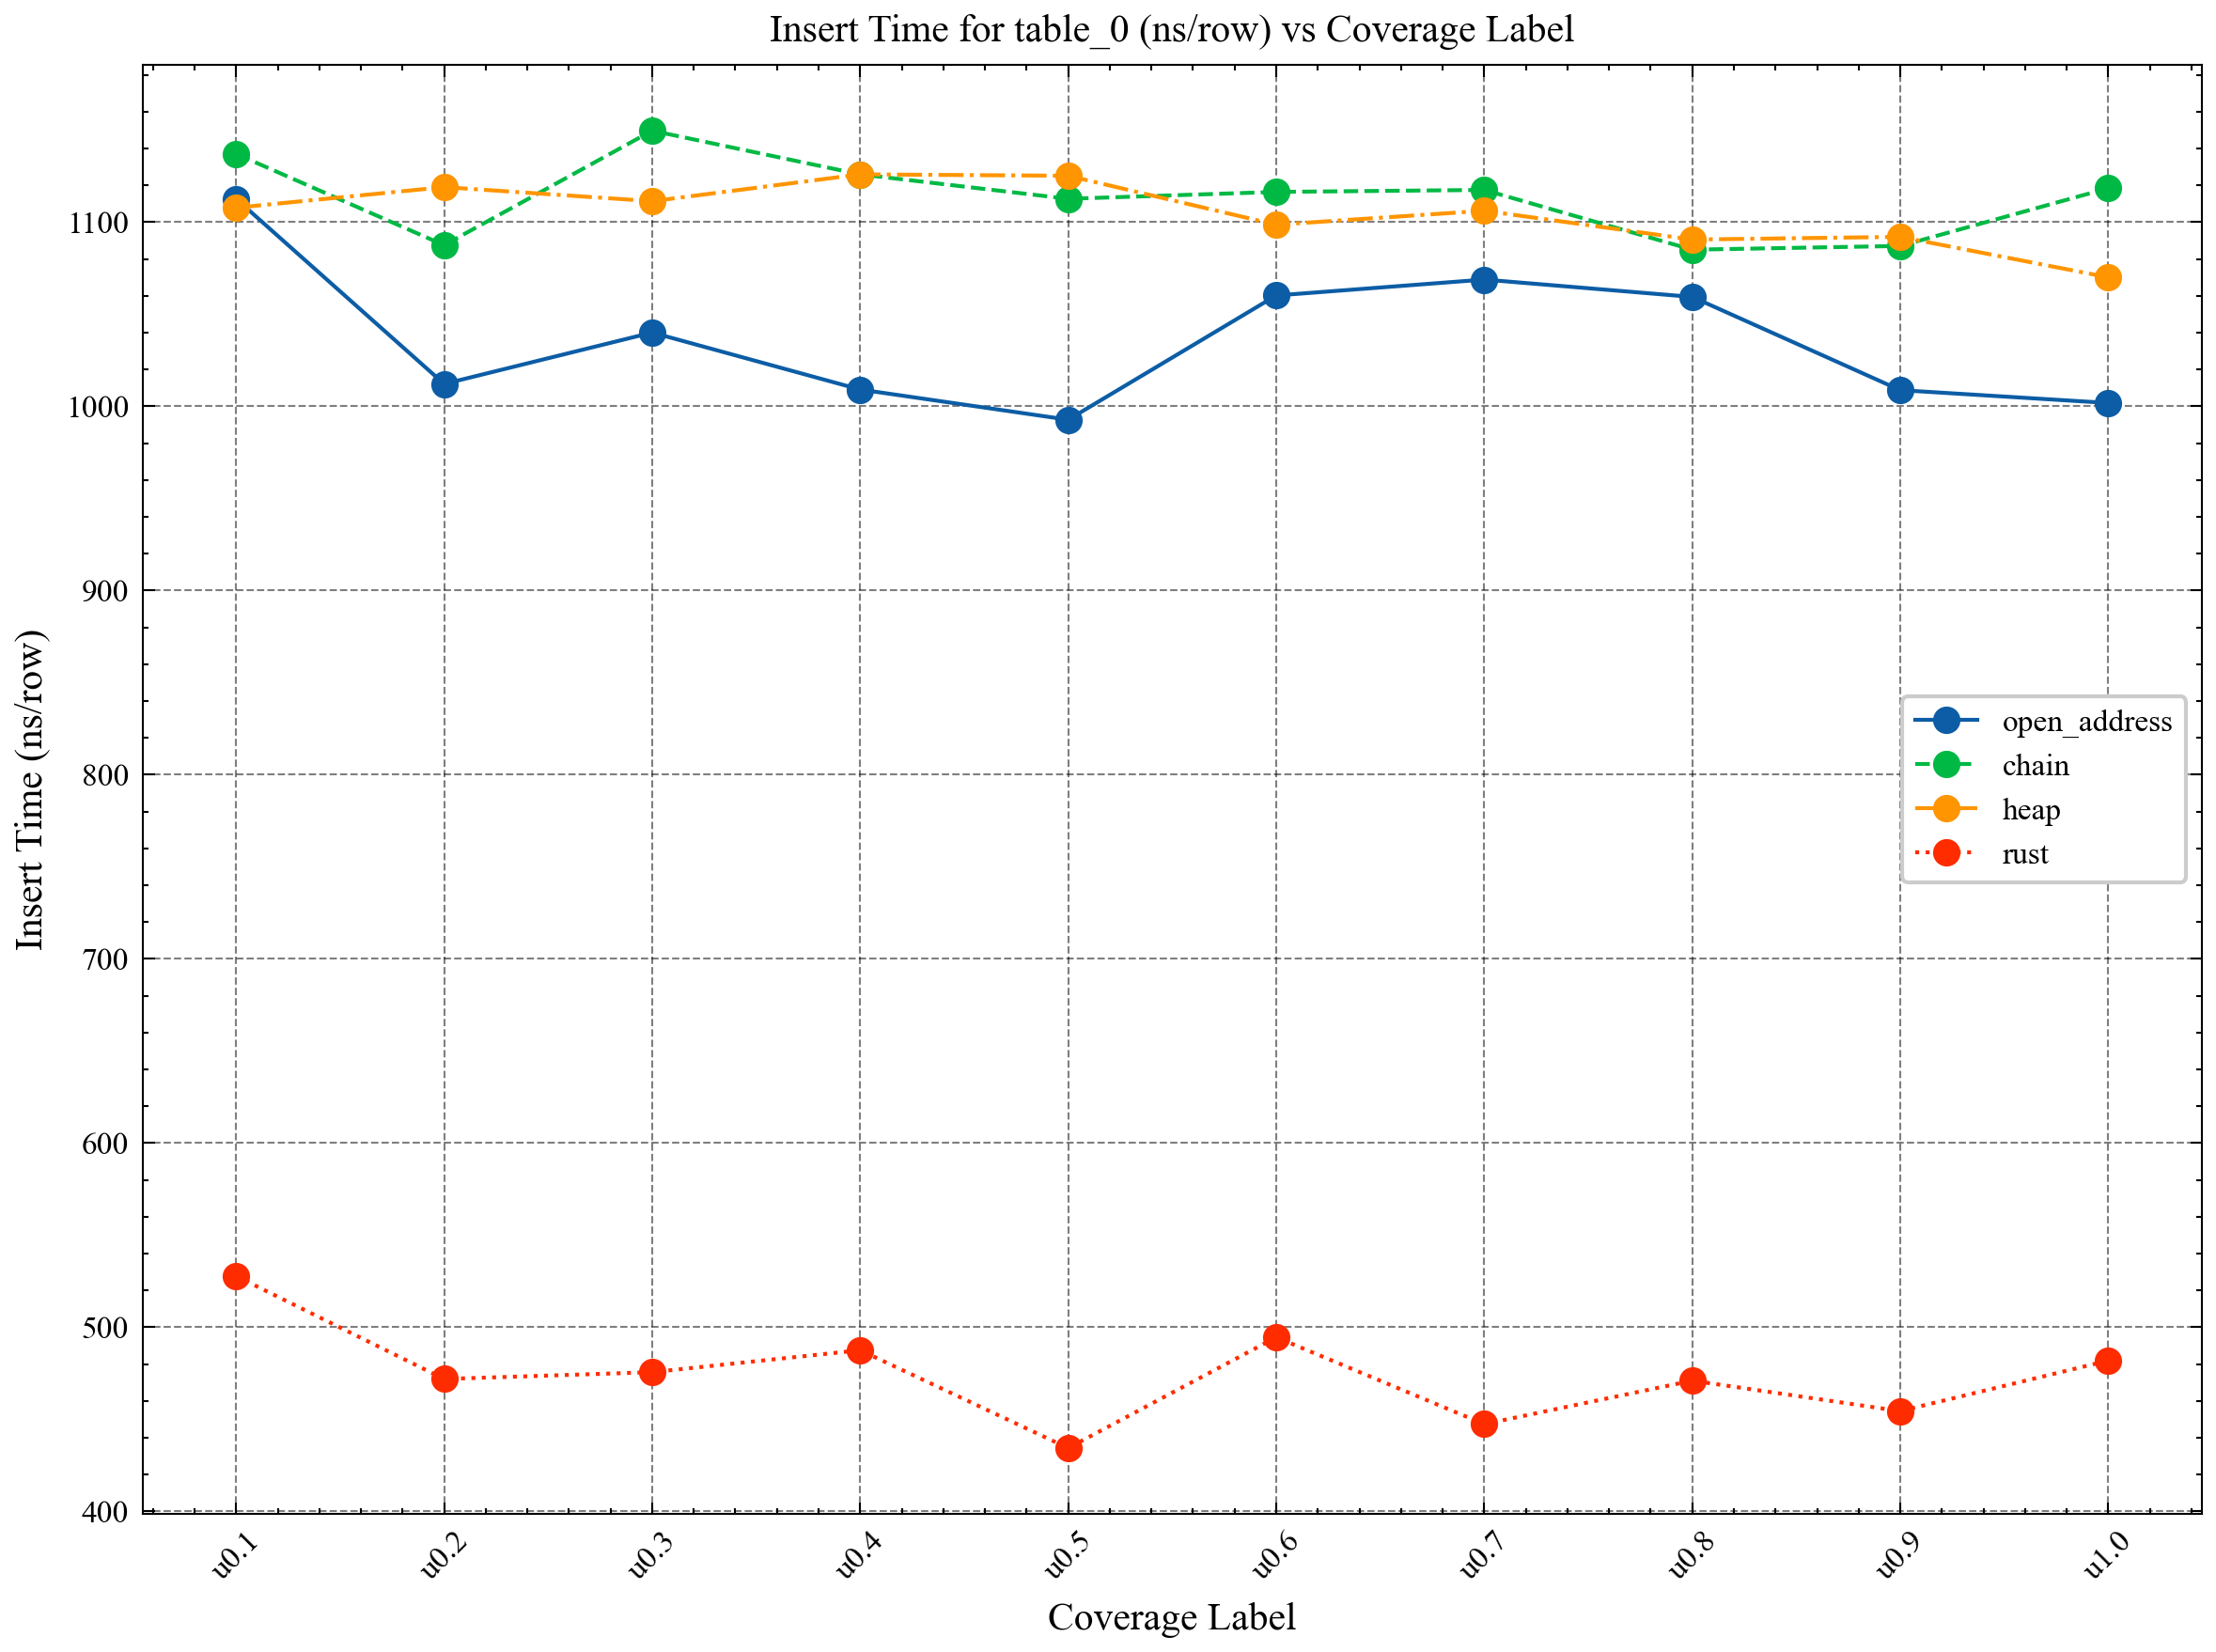

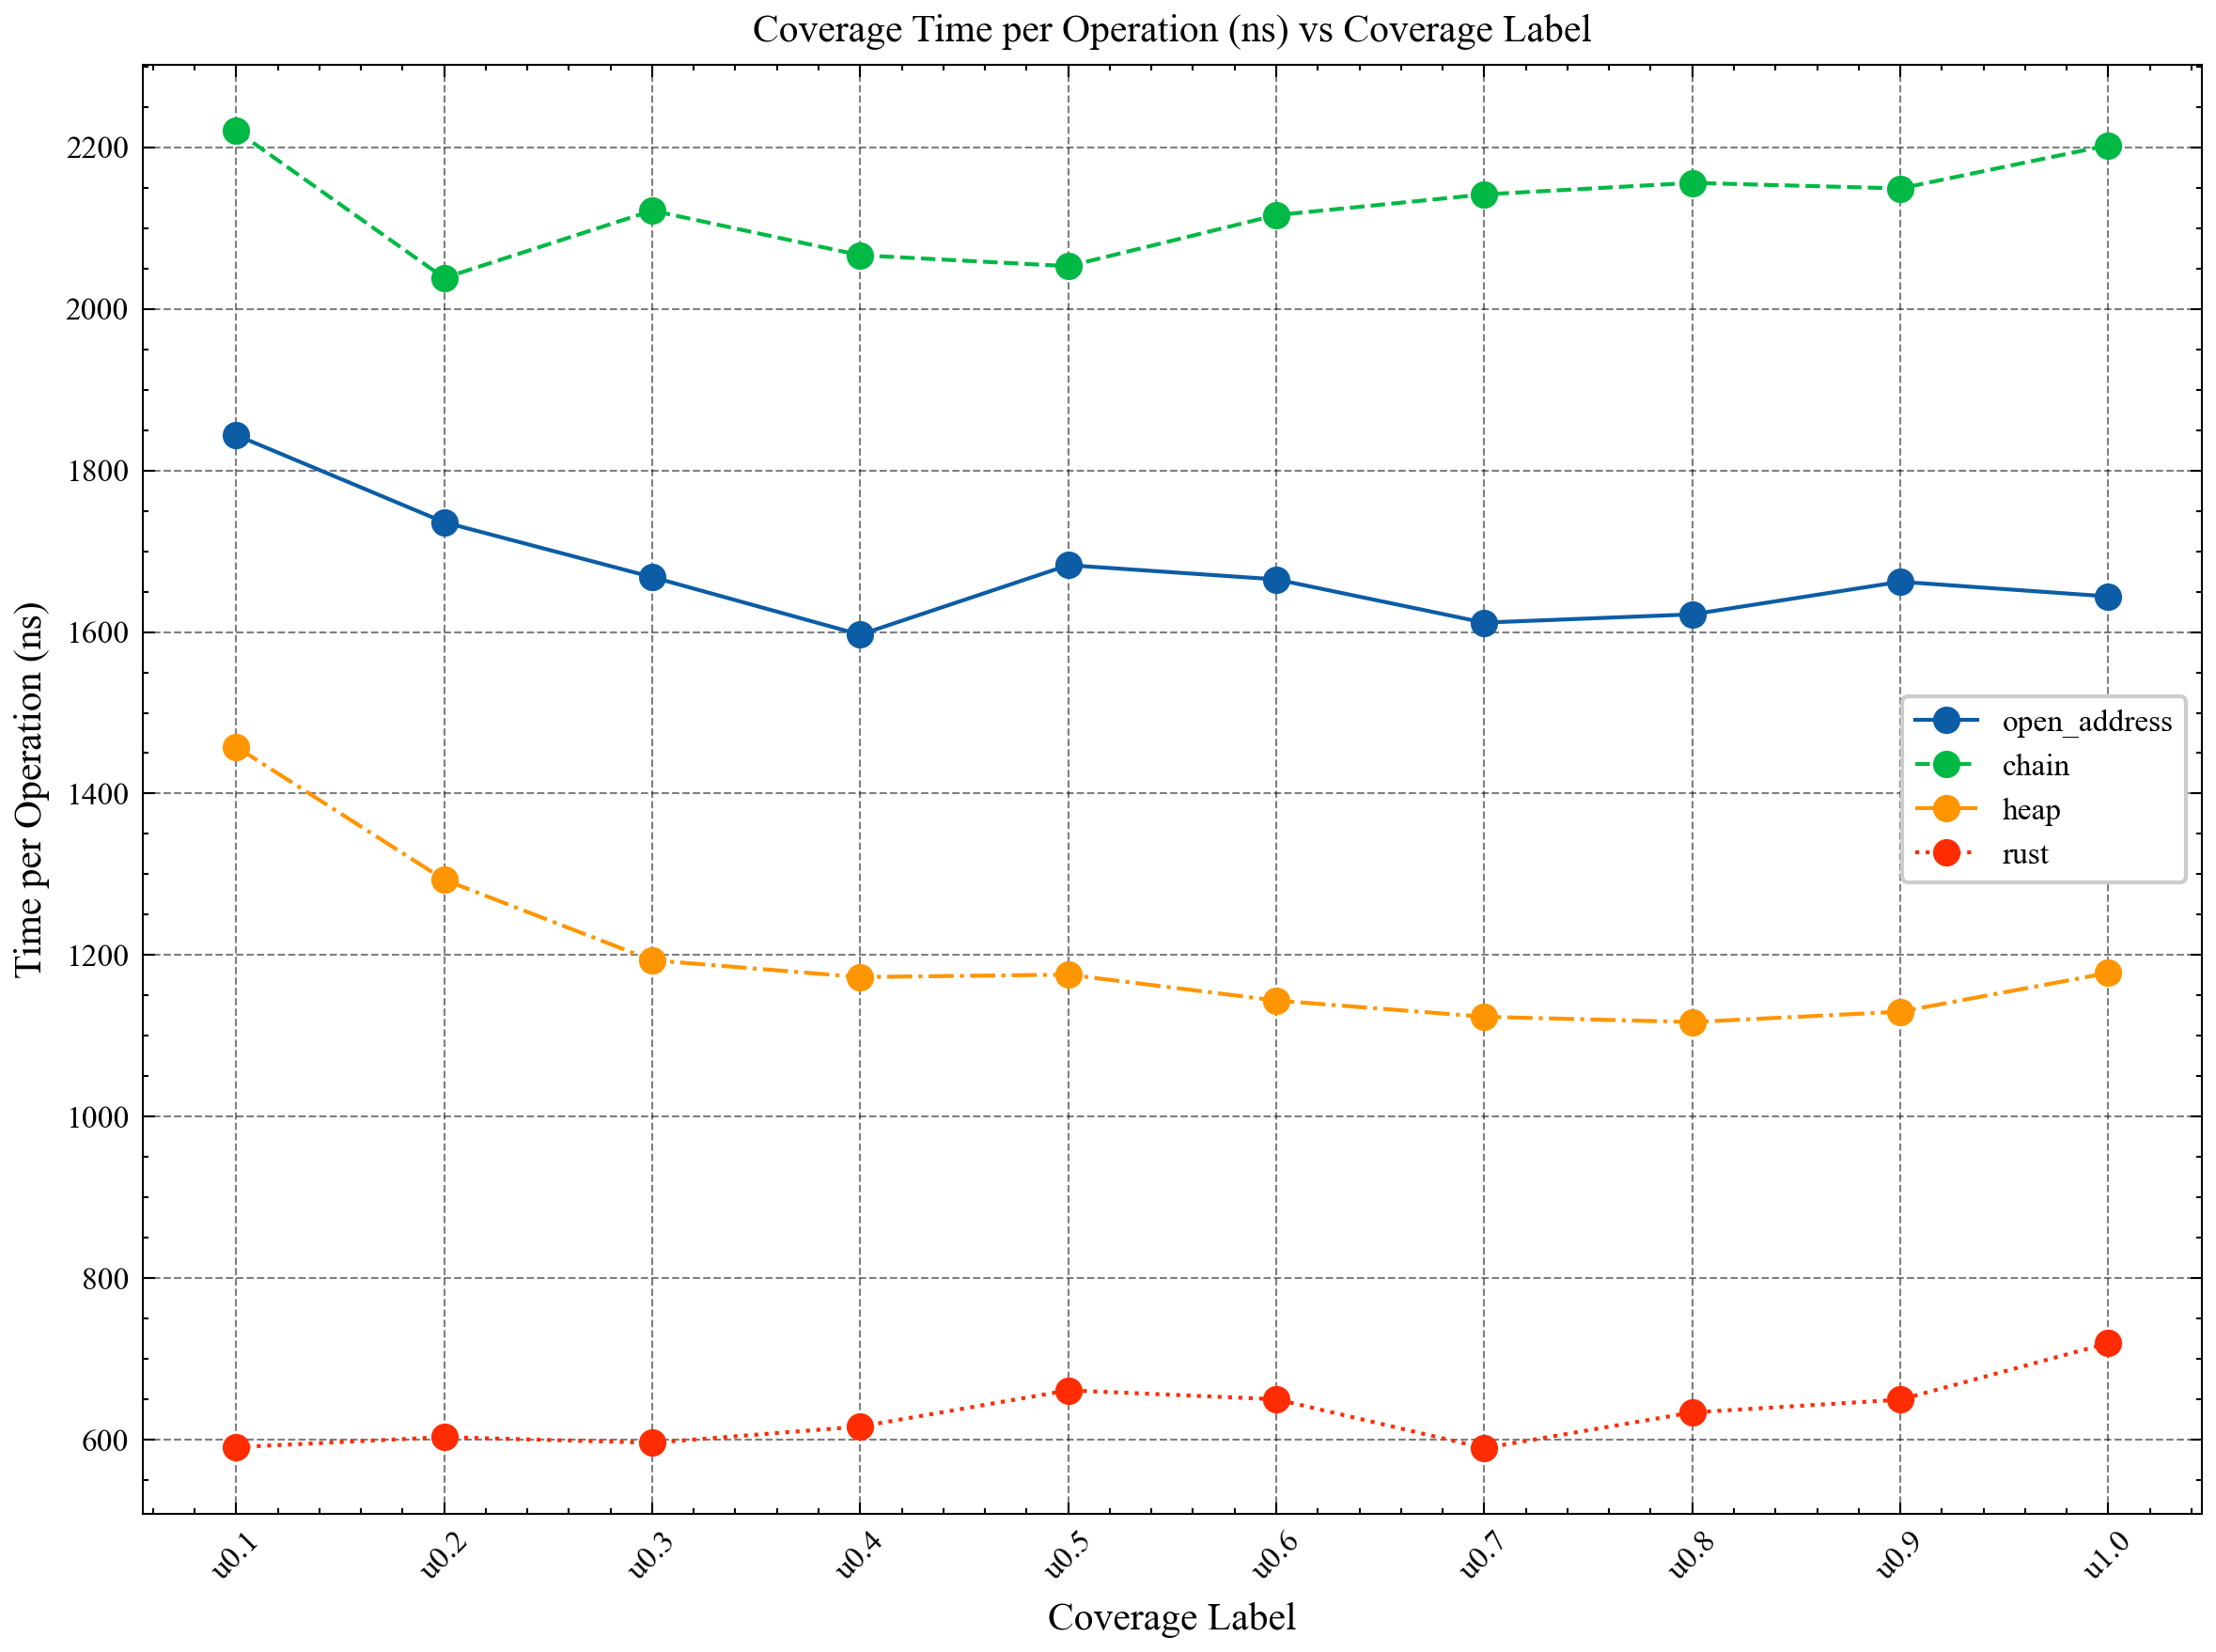

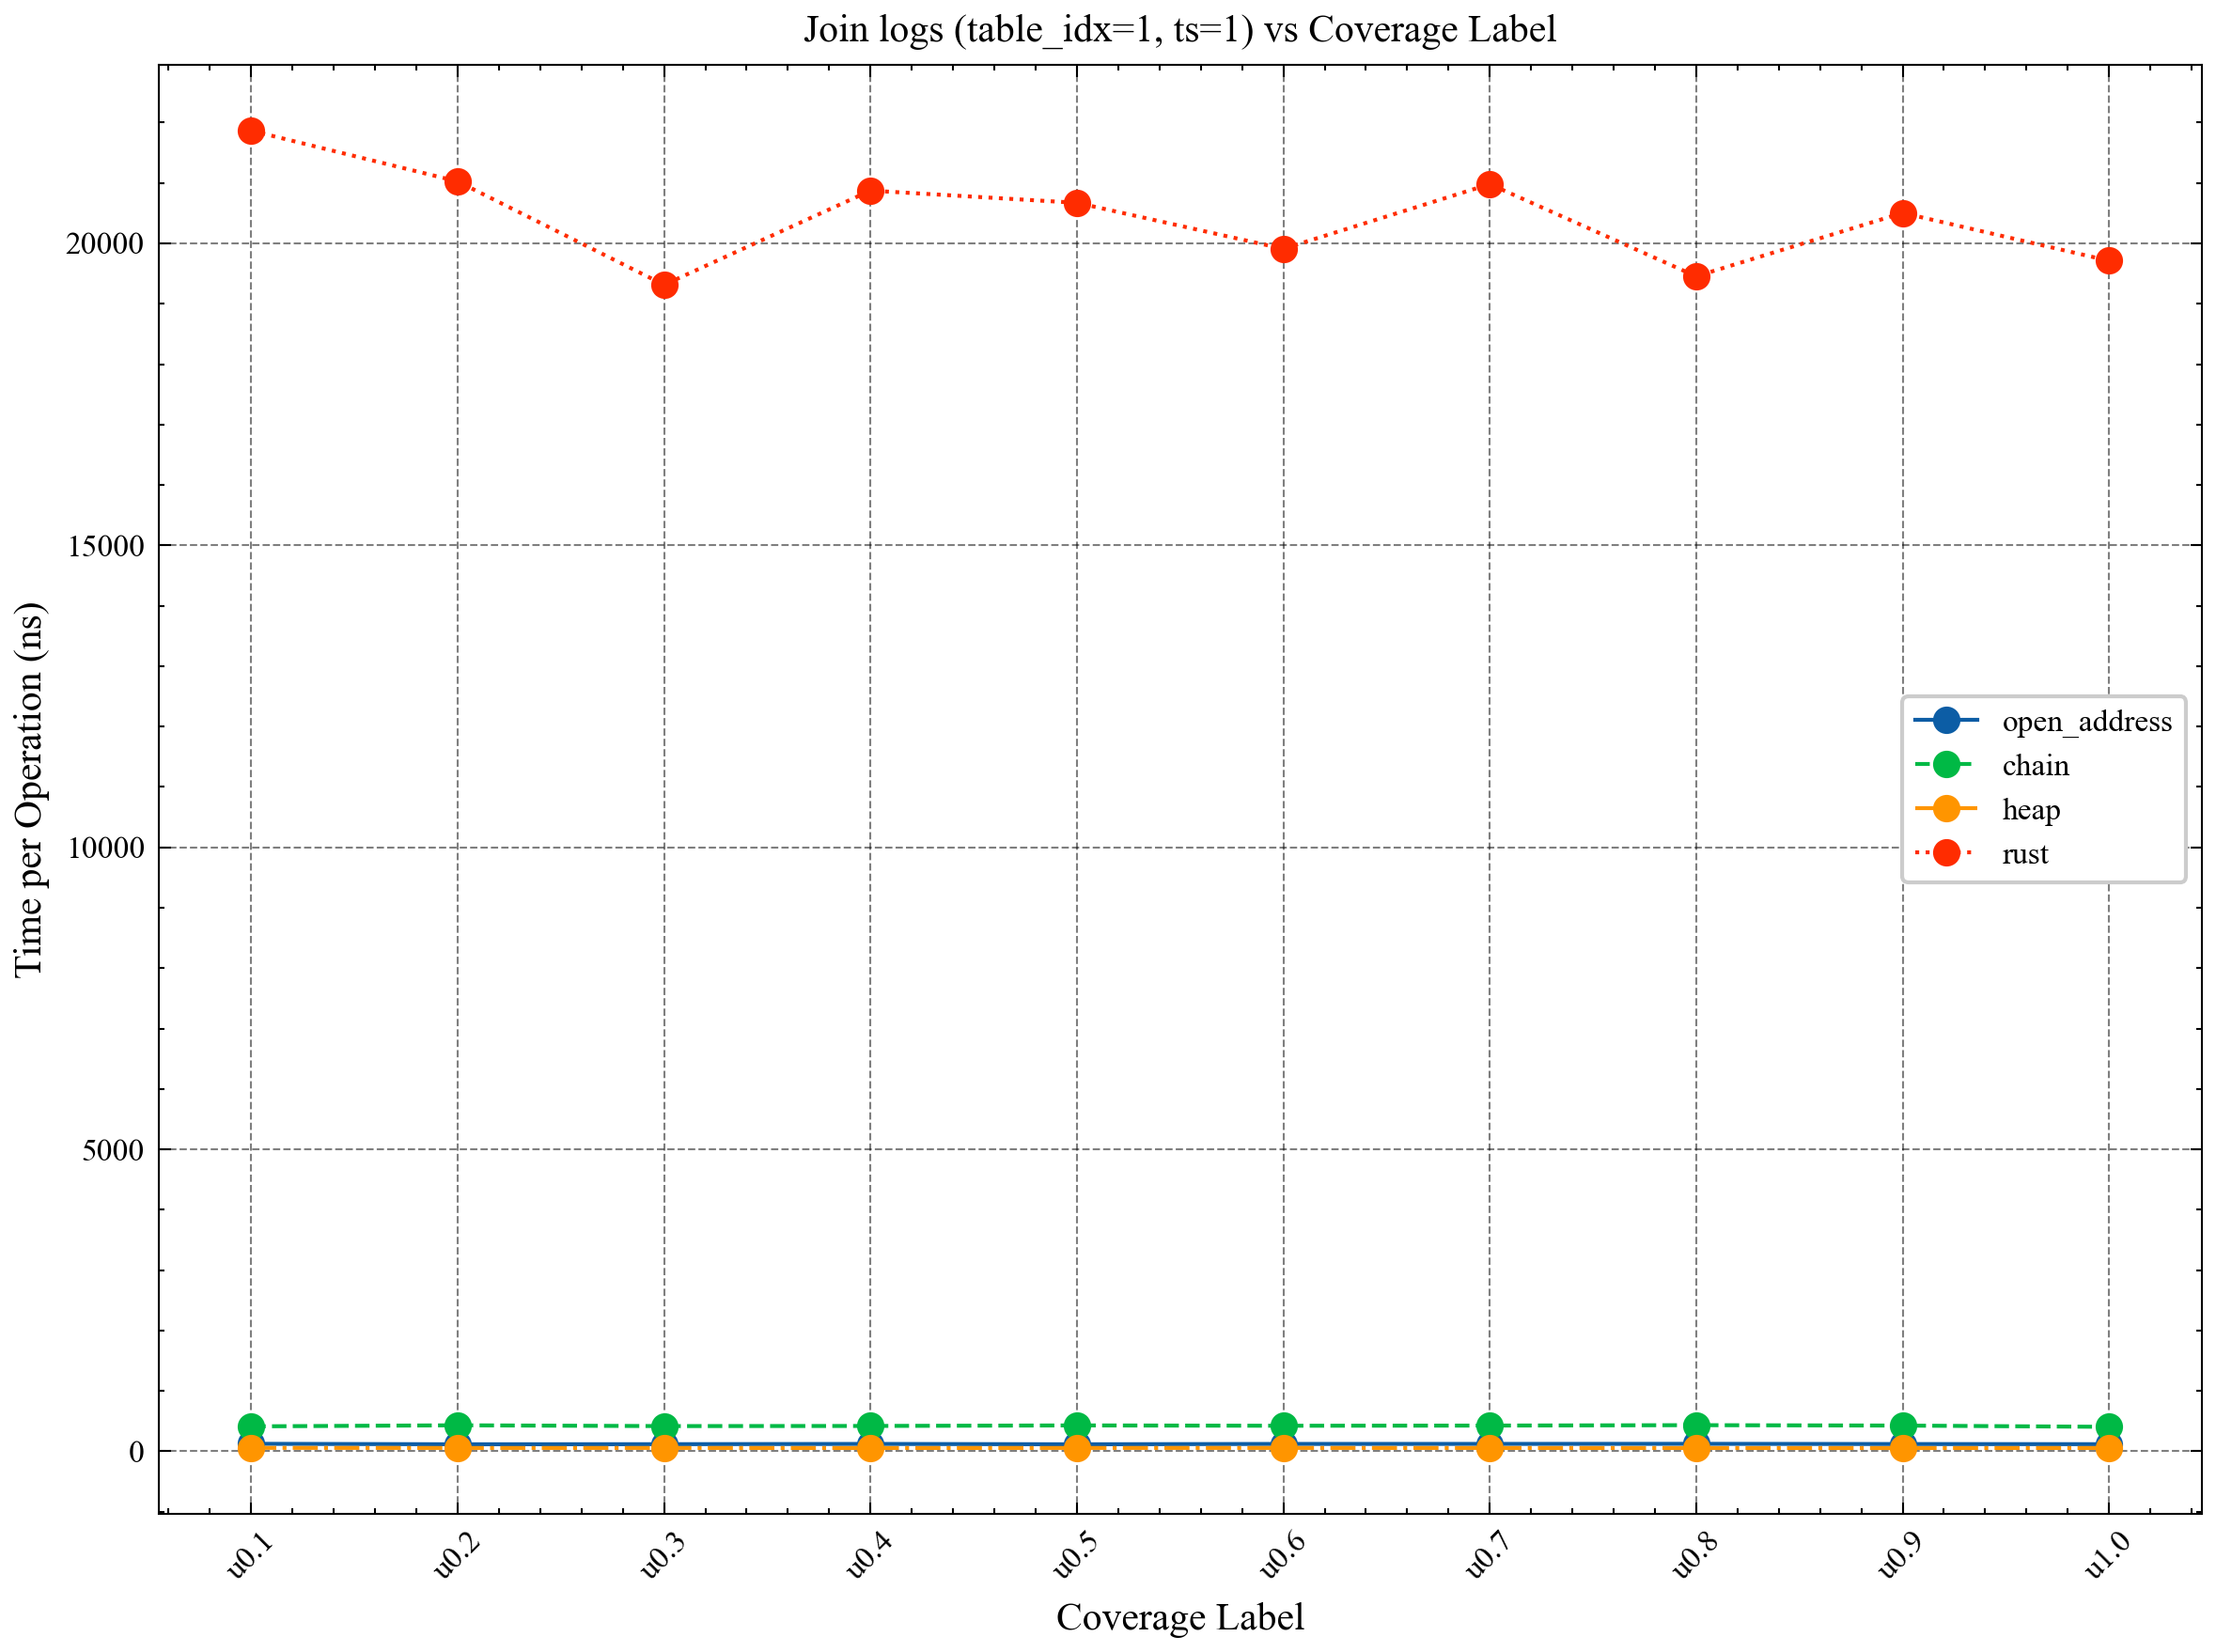

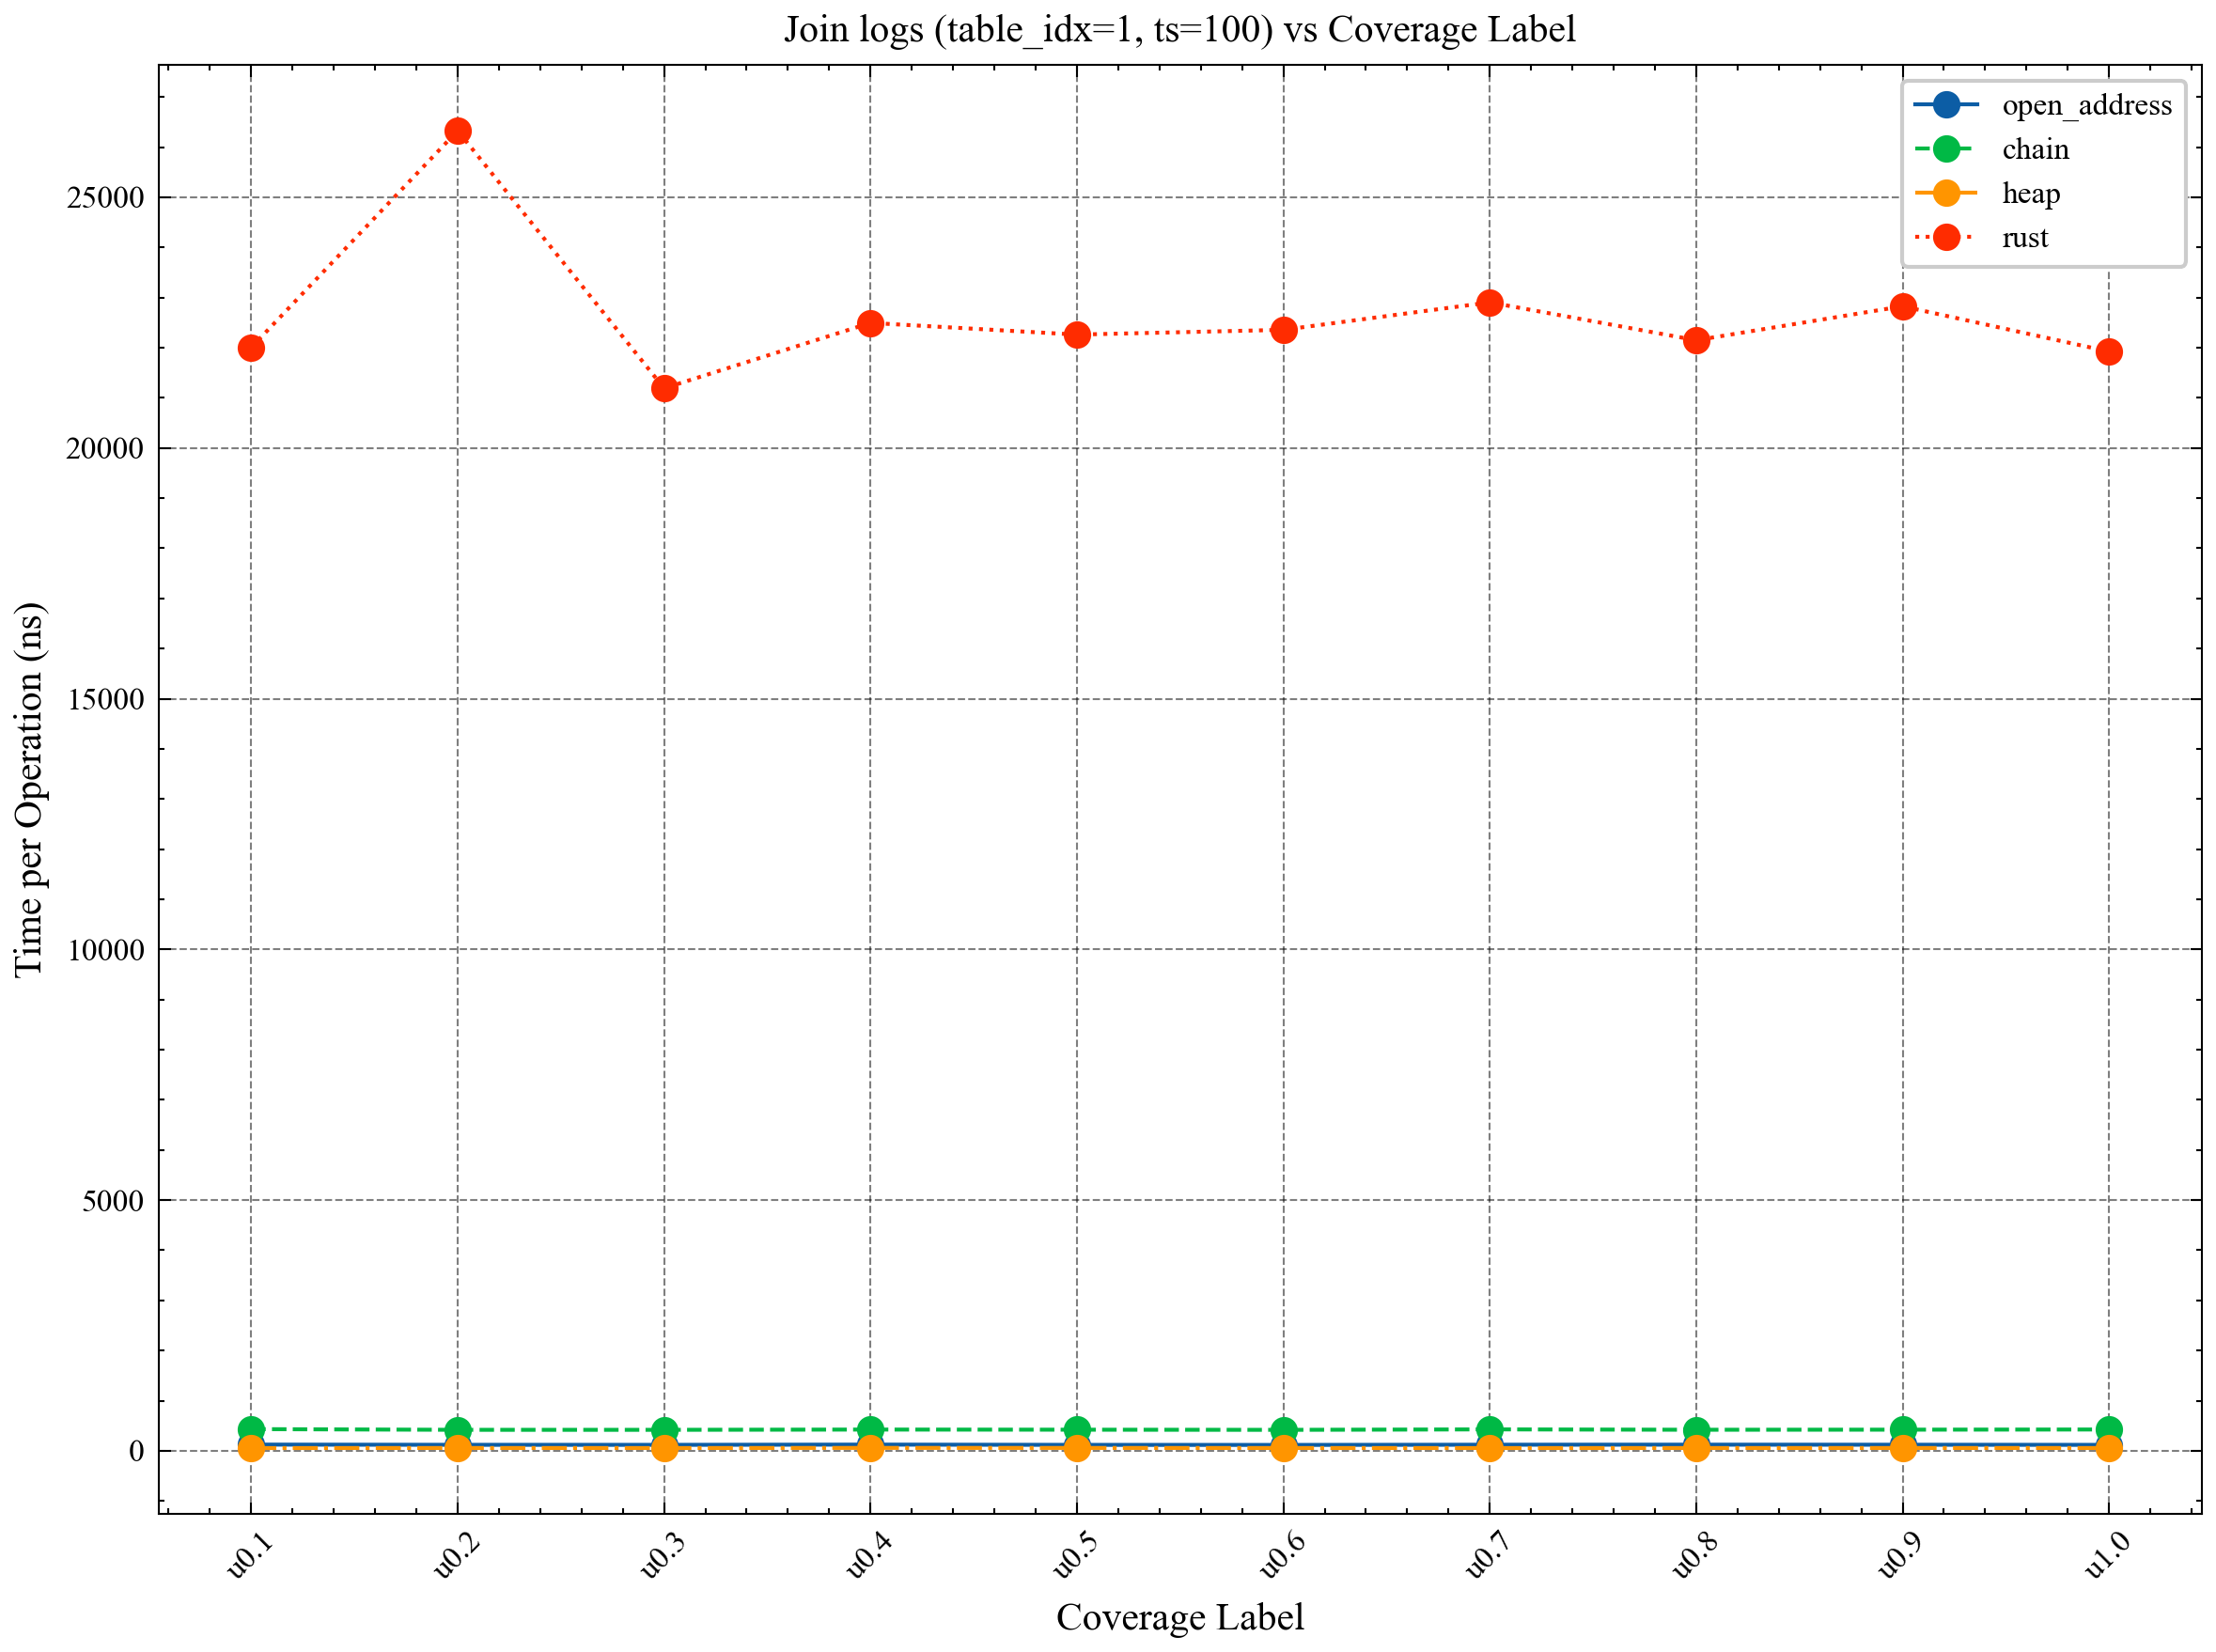

In [11]:
import subprocess
import re
import os
import math
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# If you have a custom style
plt.style.use("../custom_plt_sytle.mplstyle")

# 1) (Optional) cargo build --release --bin join_simulation
print("=== Building Rust binary (join_simulation) in release mode ===")
build_cmd = ["cargo", "build", "--release", "--bin", "join_simulation"]
result = subprocess.run(build_cmd, capture_output=True, text=True)
if result.returncode != 0:
    print("[ERROR] cargo build failed.\n", result.stderr)
    raise SystemExit(1)
print("Cargo build completed successfully.\n")

# ------------------------------------------------------------------------------
# 2) Discover coverage logs => "txs_*_t0.csv"
# ------------------------------------------------------------------------------
csv_dir = os.path.abspath("csv")
if not os.path.exists(csv_dir):
    print("Error: CSV folder not found at", csv_dir)
    raise SystemExit(1)

all_files = os.listdir(csv_dir)
coverage_logs = sorted(
    f for f in all_files
    if f.startswith("txs_") and f.endswith("_t0.csv")
)
if not coverage_logs:
    print("No coverage logs found matching txs_*_t0.csv")
    raise SystemExit(0)

coverage_labels = [f[4:-7] for f in coverage_logs]  # e.g. "u0.1" from "txs_u0.1_t0.csv"
print("Discovered coverage logs:")
for lbl, f in zip(coverage_labels, coverage_logs):
    print(f"  coverage label='{lbl}' => file={f}")

# ------------------------------------------------------------------------------
# 3) Define hash table types, # of runs, and the binary path
# ------------------------------------------------------------------------------
hash_types = ["open_address", "chain", "heap", "rust"]
num_iterations = 3
binary_path = os.path.abspath(
    os.path.join("..", "..", "..", "target", "release", "join_simulation")
)
if not os.path.exists(binary_path):
    print("Error: binary not found at", binary_path)
    raise SystemExit(1)

# ------------------------------------------------------------------------------
# 4) Regex patterns to parse lines
#    1) Insert line => Inserted <N> rows from "table_0.csv" in <T> ns
#    2) Coverage or Join => Applied <ops> operations from "<file>" in <T> ns
#    3) We detect join logs via pattern: txs_join_ts(\d+)_t(\d+)\.csv
# ------------------------------------------------------------------------------
insert_re = re.compile(r"Inserted\s+(\d+)\s+rows\s+from\s+\"[^\"]+\"\s+in\s+(\d+)\s+ns")
applied_re = re.compile(r"Applied\s+(\d+)\s+operations\s+from\s+\"([^\"]+)\"\s+in\s+(\d+)\s+ns")
join_pattern = re.compile(r"^txs_join_ts(\d+)_t(\d+)\.csv$")

# We'll collect data in 3 sets:
# (A) Insert => coverage label, hash_type => insert_time_ns
# (B) Coverage => coverage label, hash_type => coverage_time_per_op
# (C) Join => coverage label, hash_type, table_idx, ts_val => join_time_per_op
insert_rows = []
coverage_rows = []
join_rows = []

# ------------------------------------------------------------------------------
# 5) For each coverage label & file, run each hash table type
# ------------------------------------------------------------------------------
for lbl, ops_file in zip(coverage_labels, coverage_logs):
    for ht in hash_types:
        print(f"\n=== coverage='{lbl}', file={ops_file}, hash_type={ht} ===")

        # We'll accumulate times
        insert_times, insert_counts = [], []
        coverage_times, coverage_counts = [], []

        # For join logs, we'll store in a dict keyed by (table_idx, ts_val) => (time_sum, op_sum)
        join_map = {}

        for iteration in range(num_iterations):
            print(f"   iteration {iteration+1}/{num_iterations}")
            cmd = [
                binary_path,
                "--csv-dir", csv_dir,
                "--table0", "table_0.csv",
                "--txs0", ops_file,
                "-t", ht
            ]
            proc = subprocess.run(cmd, capture_output=True, text=True)
            if proc.returncode != 0:
                print(f"[ERROR] coverage={lbl}, type={ht}, iteration={iteration+1}")
                print(proc.stderr)
                continue

            stdout = proc.stdout.splitlines()
            # parse line by line
            for line in stdout:
                # 1) Insert line
                m_insert = insert_re.search(line)
                if m_insert:
                    row_count = int(m_insert.group(1))
                    time_ns = int(m_insert.group(2))
                    insert_times.append(time_ns)
                    insert_counts.append(row_count)
                    continue

                # 2) Applied line
                m_applied = applied_re.search(line)
                if m_applied:
                    ops_count = int(m_applied.group(1))
                    fname_str = m_applied.group(2)
                    time_ns = int(m_applied.group(3))

                    # If it's coverage file
                    if fname_str == ops_file:
                        coverage_times.append(time_ns)
                        coverage_counts.append(ops_count)
                    else:
                        # maybe it's a join file
                        jmatch = join_pattern.match(fname_str)
                        if jmatch:
                            ts_val_str = jmatch.group(1)
                            tbl_idx_str = jmatch.group(2)
                            ts_val = int(ts_val_str)
                            tbl_idx = int(tbl_idx_str)
                            key = (tbl_idx, ts_val)
                            if key not in join_map:
                                join_map[key] = [0,0]
                            join_map[key][0] += time_ns
                            join_map[key][1] += ops_count
                    continue

                # ignore other lines

        # after iteration(s), compute average
        # A) Insert
        if insert_times and insert_counts:
            avg_insert_time_ns = sum(insert_times)/len(insert_times)
            avg_insert_count = sum(insert_counts)/len(insert_counts)
            insert_time_ns = avg_insert_time_ns / avg_insert_count
        else:
            insert_time_ns = math.nan

        # B) Coverage
        if coverage_times and coverage_counts:
            avg_cov_time_ns = sum(coverage_times)/len(coverage_times)
            avg_cov_count = sum(coverage_counts)/len(coverage_counts)
            coverage_time_per_op = avg_cov_time_ns / avg_cov_count
        else:
            coverage_time_per_op = math.nan

        # store results for coverage
        insert_rows.append({
            "coverage_str": lbl,
            "hash_type": ht,
            "insert_time_ns": insert_time_ns
        })
        coverage_rows.append({
            "coverage_str": lbl,
            "hash_type": ht,
            "time_per_op_ns": coverage_time_per_op
        })

        # C) Join logs
        # for each discovered (tbl_idx, ts_val), average time => time_sum / op_sum
        for (key, val) in join_map.items():
            (tbl_idx, ts_val) = key
            (time_sum, op_sum) = val
            if op_sum > 0:
                time_per_op = time_sum / op_sum
            else:
                time_per_op = math.nan

            join_rows.append({
                "coverage_str": lbl,
                "hash_type": ht,
                "table_idx": tbl_idx,
                "ts_val": ts_val,
                "time_per_op_ns": time_per_op
            })

# ------------------------------------------------------------------------------
# 6) Build DataFrames: insert_df, coverage_df, join_df
# ------------------------------------------------------------------------------
insert_df = pd.DataFrame(insert_rows)
coverage_df = pd.DataFrame(coverage_rows)
join_df = pd.DataFrame(join_rows)

print("\n=== Insert DF ===")
print(insert_df)
print("\n=== Coverage DF ===")
print(coverage_df)
print("\n=== Join DF ===")
print(join_df)

if insert_df.empty and coverage_df.empty and join_df.empty:
    print("No valid results. Exiting.")
    raise SystemExit(0)

# We'll define an order for coverage labels
label_order = coverage_labels
label_idx_map = {c:i for i,c in enumerate(label_order)}

# ------------------------------------------------------------------------------
# A) Insert Time per row vs coverage label
# ------------------------------------------------------------------------------
if not insert_df.empty:
    insert_df["x_pos"] = insert_df["coverage_str"].map(label_idx_map)
    x_ticks = np.arange(len(label_order))

    plt.figure(figsize=(8,6))
    for ht in hash_types:
        sub = insert_df[insert_df["hash_type"]==ht].copy()
        sub.sort_values("x_pos", inplace=True)
        plt.plot(sub["x_pos"], sub["insert_time_ns"], marker="o", label=ht)
    plt.title("Insert Time for table_0 (ns/row) vs Coverage Label")
    plt.xlabel("Coverage Label")
    plt.ylabel("Insert Time (ns/row)")
    plt.xticks(x_ticks, label_order, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# B) Coverage time per op vs coverage label
# ------------------------------------------------------------------------------
if not coverage_df.empty:
    coverage_df["x_pos"] = coverage_df["coverage_str"].map(label_idx_map)
    x_ticks = np.arange(len(label_order))

    plt.figure(figsize=(8,6))
    for ht in hash_types:
        sub = coverage_df[coverage_df["hash_type"]==ht].copy()
        sub.sort_values("x_pos", inplace=True)
        plt.plot(sub["x_pos"], sub["time_per_op_ns"], marker="o", label=ht)
    plt.title("Coverage Time per Operation (ns) vs Coverage Label")
    plt.xlabel("Coverage Label")
    plt.ylabel("Time per Operation (ns)")
    plt.xticks(x_ticks, label_order, rotation=45)
    plt.legend()
    plt.tight_layout()
    plt.show()

# ------------------------------------------------------------------------------
# C) Join logs => 1 chart per (table_idx, ts_val)
# ------------------------------------------------------------------------------
if not join_df.empty:
    # gather distinct (table_idx, ts_val) pairs
    pairs = join_df[["table_idx","ts_val"]].drop_duplicates().values.tolist()
    # sort them
    pairs.sort(key=lambda x: (x[0], x[1]))

    for (tid, tsval) in pairs:
        sub = join_df[(join_df["table_idx"]==tid) & (join_df["ts_val"]==tsval)].copy()
        sub["x_pos"] = sub["coverage_str"].map(label_idx_map)
        sub.sort_values("x_pos", inplace=True)

        plt.figure(figsize=(8,6))
        for ht in hash_types:
            sub_ht = sub[sub["hash_type"]==ht]
            plt.plot(sub_ht["x_pos"], sub_ht["time_per_op_ns"], marker="o", label=ht)

        plt.title(f"Join logs (table_idx={tid}, ts={tsval}) vs Coverage Label")
        plt.xlabel("Coverage Label")
        plt.ylabel("Time per Operation (ns)")
        x_ticks = np.arange(len(label_order))
        plt.xticks(x_ticks, label_order, rotation=45)
        plt.legend()
        plt.tight_layout()
        plt.show()
